# Overfitting minimal set of intervals

## imports

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

PAL_MODALITIES = {
    "rna_seq": "#717EC3",
    "splice_site": "#AE8799",
    "splice_usage": "#C95D63",
    "splice_junctions": "#EE8434"
}

MAP_MODALITIES = {
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
}

OUTPUT_DIR = os.path.join("pdfs","overfitting_dev")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [ ]:
# paths

ROOT = ".."
RESULTS_DIR = os.path.join(ROOT,"results")
OUTPUT_DIR = os.path.join(ROOT,"results/bsc/finetuning/alphagenome_pytorch/full")
logs_file = os.path.join(OUTPUT_DIR, "summary", "epoch_logs.parquet")

EVAL_DIR = os.path.join(RESULTS_DIR,"bsc","evaluation","alphagenome_pytorch","full")
RUNS_OI = ["randinit__newloss__annotated__frozen__multigpu_ddp__alpha5"]
EPOCHS_OI = [1, 2, 3, 4, 5, 10]
SUBSETS_OI = ["test", "train_sample"]

PREDS_DIR = os.path.join(EVAL_DIR, RUNS_OI[0], "epoch10", "test", "predictions")
pred_files = {
    "rna_seq_per_gene": os.path.join(PREDS_DIR,"rna_seq_per_gene.parquet"),
    "splice_site_scores": os.path.join(PREDS_DIR,"splice_site_scores.parquet"),
    "ssu_scores": os.path.join(PREDS_DIR,"ssu_scores.parquet"),
    "junction_totals": os.path.join(PREDS_DIR,"junction_totals.parquet"),
    "junction_scores": os.path.join(PREDS_DIR,"junction_scores.parquet"),
    "psi_scores": os.path.join(PREDS_DIR,"psi_scores.parquet"),
}

In [ ]:
preds = {k: pd.read_parquet(f) for k, f in pred_files.items()}


In [ ]:
# loads

logs = pd.read_parquet(logs_file)
preds = {k: pd.read_parquet(f) for k, f in pred_files.items()}

# Load metrics across epochs and subsets (test + train_sample)
metrics_epochs = []
for run_name in RUNS_OI:
    for epoch in EPOCHS_OI:
        for subset in SUBSETS_OI:
            fpath = os.path.join(EVAL_DIR, run_name, "epoch{}".format(epoch), subset, "metrics.parquet")
            if os.path.exists(fpath):
                df = pd.read_parquet(fpath)
                df["run_name"] = run_name
                df["epoch"] = epoch
                df["subset"] = subset
                metrics_epochs.append(df)
metrics_epochs = pd.concat(metrics_epochs, ignore_index=True)

## figures

### evaluation metrics

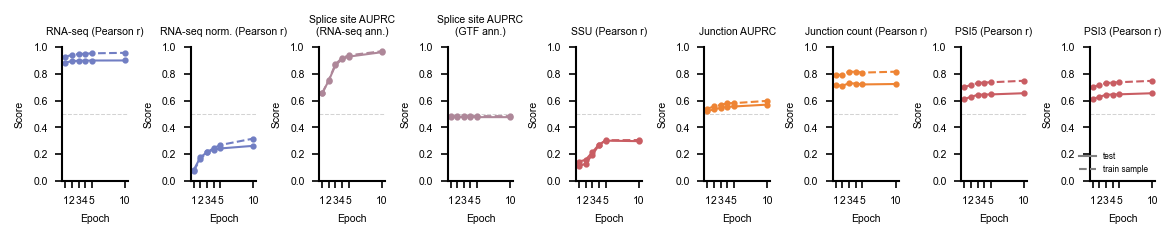

In [ ]:
METRICS_OI = [
    "gene_expr_raw_mean",
    "gene_expr_norm_across_genes_mean",
    "splice_site_auprc_macro_rnaseq",
    "splice_site_auprc_macro_gtf",
    "ssu_pearson_r_mean",
    "junction_auprc_mean",
    "junction_count_pearson_r_mean",
    "psi5_pearson_r_mean",
    "psi3_pearson_r_mean",
]

MAP_LABELS = {
    "gene_expr_raw_mean": "RNA-seq (Pearson r)",
    "gene_expr_norm_across_genes_mean": "RNA-seq norm. (Pearson r)",
    "splice_site_auprc_macro_rnaseq": "Splice site AUPRC\n(RNA-seq ann.)",
    "splice_site_auprc_macro_gtf": "Splice site AUPRC\n(GTF ann.)",
    "ssu_pearson_r_mean": "SSU (Pearson r)",
    "junction_auprc_mean": "Junction AUPRC",
    "junction_count_pearson_r_mean": "Junction count (Pearson r)",
    "psi5_pearson_r_mean": "PSI5 (Pearson r)",
    "psi3_pearson_r_mean": "PSI3 (Pearson r)",
}

PAL_METRIC_GROUPS = {
    "gene_expr": PAL_MODALITIES["rna_seq"],
    "splice_site": PAL_MODALITIES["splice_site"],
    "ssu_pearson": PAL_MODALITIES["splice_usage"],
    "junction_auprc": PAL_MODALITIES["splice_junctions"],
    "junction_count": PAL_MODALITIES["splice_junctions"],
    "psi5_pearson": PAL_MODALITIES["splice_usage"],
    "psi3_pearson": PAL_MODALITIES["splice_usage"],
}

SUBSET_LINESTYLE = {
    "test": "-",
    "train_sample": "--",
}

x = (
    metrics_epochs
    .query("metric_name.isin(@METRICS_OI)")
    .assign(label=lambda d: d["metric_name"].map(MAP_LABELS))
    .assign(color=lambda d: d["metric_group"].map(PAL_METRIC_GROUPS))
)

n_metrics = len(METRICS_OI)
fig, axes = plt.subplots(
    1, n_metrics,
    figsize=(n_metrics * 2.2 * cm, 4 * cm),
    sharey=False,
)

for ax, metric_name in zip(axes, METRICS_OI):
    sub = x.query("metric_name == @metric_name")
    color = PAL_METRIC_GROUPS.get(sub["metric_group"].iloc[0], "gray")
    for subset, ls in SUBSET_LINESTYLE.items():
        sub_s = sub.query("subset == @subset")
        if sub_s.empty:
            continue
        ax.plot(
            sub_s["epoch"], sub_s["value"],
            color=color, linewidth=1, marker="o", markersize=2,
            linestyle=ls,
            label=subset,
        )
    ax.set_title(MAP_LABELS[metric_name], fontsize=5)
    ax.set_xlabel("Epoch", fontsize=5)
    ax.set_ylabel("Score", fontsize=5)
    ax.set_xticks(EPOCHS_OI)
    ax.tick_params(labelsize=5)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color="lightgray", linestyle="--", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

# shared legend (test = solid, train_sample = dashed)
handles = [
    plt.Line2D([0], [0], color="gray", linewidth=1, linestyle="-", label="test"),
    plt.Line2D([0], [0], color="gray", linewidth=1, linestyle="--", label="train sample"),
]
axes[-1].legend(handles=handles, fontsize=4, frameon=False, loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join("pdfs", "evaluation_metrics.pdf"), bbox_inches="tight")
plt.show()

In [ ]:
logs.value_counts(["run_name"])

run_name                                          
randinit__newloss__annotated__frozen__multigpu_ddp    10
Name: count, dtype: int64

### splice site and junction heads struggle to overfit a single interval

In [ ]:
X = logs#.query("run_name.isin(@runs_oi)")

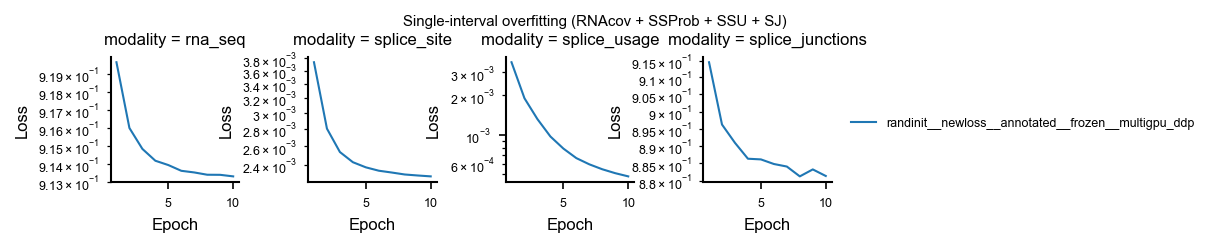

In [ ]:
x = (
    X[
        ["epoch","run_name","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name", palette="tab20",
    col="modality", col_order=PAL_MODALITIES.keys(),
    linewidth=1,
    facet_kws=dict(sharey=False),
    height=4*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Single-interval overfitting (RNAcov + SSProb + SSU + SJ)")

plt.show()

## performance on held-out intervals

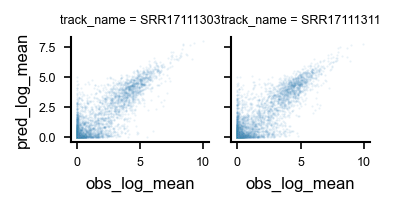

In [ ]:
X = preds["rna_seq_per_gene"]

g = sns.relplot(
    kind="scatter",
    data=X,
    x="obs_log_mean",
    y="pred_log_mean",
    col="track_name",
    s=1, alpha=0.1,
    height=3.5*cm, aspect=0.9
)

g.set_titles(size=6)

plt.show()

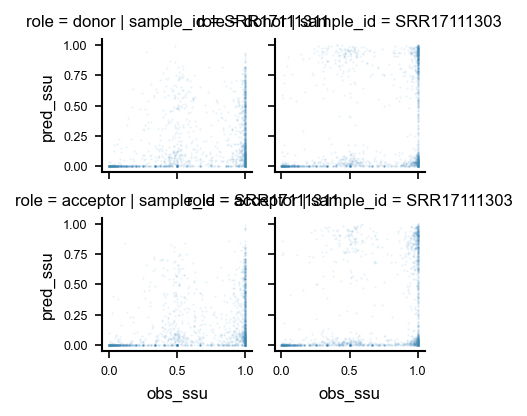

In [ ]:
X = preds["ssu_scores"].sample(10000)

g = sns.relplot(
    kind="scatter",
    data=X,
    x="obs_ssu",
    y="pred_ssu",
    col="sample_id",
    row="role",
    s=1, alpha=0.1,
    height=3.5*cm, aspect=1
)

plt.show()

In [ ]:
X.sort_values("obs_ssu").tail()

,chrom,exon_pos_1based,strand,role,sample_id,pred_ssu,obs_ssu
617010,chr3,39093874,+,acceptor,SRR17111311,0.214844,1.0
640597,chr20,1052446,-,donor,SRR17111311,0.000223,1.0
776119,chr3,37998364,+,donor,SRR17111303,0.515625,1.0
557978,chr2,196640209,-,donor,SRR17111303,0.000025,1.0
1438481,chr3,129156855,-,acceptor,SRR17111303,0.020996,1.0


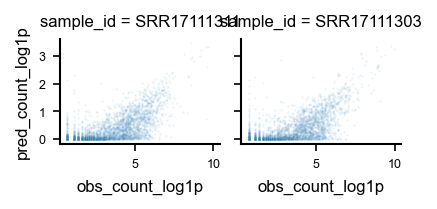

In [ ]:
X = preds["junction_scores"].query("obs_count > 0").sample(10000, random_state=42)
X["obs_count_log1p"] = np.log1p(X["obs_count"])
X["pred_count_log1p"] = np.log1p(X["pred_count"])

g = sns.relplot(
    kind="scatter",
    data=X,
    x="obs_count_log1p",
    y="pred_count_log1p",
    col="sample_id",
    s=1, alpha=0.1,
    height=3.5*cm, aspect=1
)

plt.show()

## WT vs MUT delta

In [ ]:
from scipy import stats

WT_SAMPLE = "SRR17111303"
MUT_SAMPLE = "SRR17111311"

### RNA-seq gene expression delta

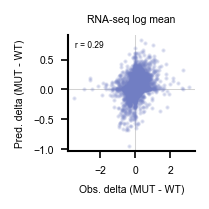

In [ ]:
X = preds["rna_seq_per_gene"]

wt = X.query("track_name == @WT_SAMPLE").set_index("gene_id")[["obs_log_mean", "pred_log_mean"]]
mut = X.query("track_name == @MUT_SAMPLE").set_index("gene_id")[["obs_log_mean", "pred_log_mean"]]

delta = pd.DataFrame({
    "obs_delta": mut["obs_log_mean"] - wt["obs_log_mean"],
    "pred_delta": mut["pred_log_mean"] - wt["pred_log_mean"],
}).dropna()

r, p = stats.pearsonr(delta["obs_delta"], delta["pred_delta"])

fig, ax = plt.subplots(figsize=(3.5 * cm, 3.5 * cm))
ax.scatter(delta["obs_delta"], delta["pred_delta"],
           s=1, alpha=0.2, rasterized=True,
           color=PAL_MODALITIES["rna_seq"])
ax.set_xlabel("Obs. delta (MUT - WT)", fontsize=5)
ax.set_ylabel("Pred. delta (MUT - WT)", fontsize=5)
ax.set_title("RNA-seq log mean", fontsize=5)
ax.text(0.05, 0.95, "r = {:.2f}".format(r), transform=ax.transAxes,
        fontsize=4, va="top")
ax.tick_params(labelsize=5)
ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### SSU delta

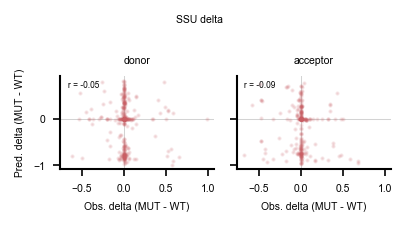

In [ ]:
X = preds["ssu_scores"].sample(10000)
KEY = ["chrom", "exon_pos_1based", "strand", "role"]

wt = X.query("sample_id == @WT_SAMPLE").set_index(KEY)[["obs_ssu", "pred_ssu"]]
mut = X.query("sample_id == @MUT_SAMPLE").set_index(KEY)[["obs_ssu", "pred_ssu"]]

delta_ssu = wt.join(mut, lsuffix="_wt", rsuffix="_mut", how="inner")
delta_ssu["obs_delta"] = delta_ssu["obs_ssu_mut"] - delta_ssu["obs_ssu_wt"]
delta_ssu["pred_delta"] = delta_ssu["pred_ssu_mut"] - delta_ssu["pred_ssu_wt"]
delta_ssu = delta_ssu.reset_index().dropna(subset=["obs_delta", "pred_delta"])

fig, axes = plt.subplots(1, 2, figsize=(7 * cm, 3.5 * cm), sharey=True, sharex=True)
for ax, role in zip(axes, ["donor", "acceptor"]):
    sub = delta_ssu.query("role == @role").sample(min(10000, len(delta_ssu.query("role == @role"))), random_state=42)
    r, _ = stats.pearsonr(sub["obs_delta"], sub["pred_delta"])
    ax.scatter(sub["obs_delta"], sub["pred_delta"],
               s=1, alpha=0.15, rasterized=True,
               color=PAL_MODALITIES["splice_usage"])
    ax.set_title(role, fontsize=5)
    ax.set_xlabel("Obs. delta (MUT - WT)", fontsize=5)
    ax.set_ylabel("Pred. delta (MUT - WT)" if ax is axes[0] else "", fontsize=5)
    ax.text(0.05, 0.95, "r = {:.2f}".format(r), transform=ax.transAxes,
            fontsize=4, va="top")
    ax.tick_params(labelsize=5)
    ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
    ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

fig.suptitle("SSU delta", fontsize=5, y=1.02)
plt.tight_layout()
plt.show()

### Junction count delta

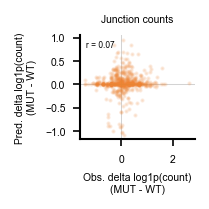

In [ ]:
X = preds["junction_scores"].query("obs_count > 0").sample(10000, random_state=42)
KEY = ["chrom", "donor_pos_1based", "acceptor_pos_1based", "strand"]

wt = X.query("sample_id == @WT_SAMPLE").set_index(KEY)[["obs_count", "pred_count"]]
mut = X.query("sample_id == @MUT_SAMPLE").set_index(KEY)[["obs_count", "pred_count"]]

# inner join: only junctions present in both conditions
delta_junc = wt.join(mut, lsuffix="_wt", rsuffix="_mut", how="inner")

# keep junctions with obs_count > 0 in at least one condition
delta_junc = delta_junc.query("obs_count_wt > 0 or obs_count_mut > 0")

# log1p-space delta (logFC-like)
delta_junc["obs_delta"] = np.log1p(delta_junc["obs_count_mut"]) - np.log1p(delta_junc["obs_count_wt"])
delta_junc["pred_delta"] = np.log1p(delta_junc["pred_count_mut"]) - np.log1p(delta_junc["pred_count_wt"])
delta_junc = delta_junc.dropna(subset=["obs_delta", "pred_delta"])

sub = delta_junc.sample(min(20000, len(delta_junc)), random_state=42)
r, _ = stats.pearsonr(sub["obs_delta"], sub["pred_delta"])

fig, ax = plt.subplots(figsize=(3.5 * cm, 3.5 * cm))
ax.scatter(sub["obs_delta"], sub["pred_delta"],
           s=1, alpha=0.15, rasterized=True,
           color=PAL_MODALITIES["splice_junctions"])
ax.set_xlabel("Obs. delta log1p(count)\n(MUT - WT)", fontsize=5)
ax.set_ylabel("Pred. delta log1p(count)\n(MUT - WT)", fontsize=5)
ax.set_title("Junction counts", fontsize=5)
ax.text(0.05, 0.95, "r = {:.2f}".format(r), transform=ax.transAxes,
        fontsize=4, va="top")
ax.tick_params(labelsize=5)
ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

### PSI delta (PSI5 and PSI3)

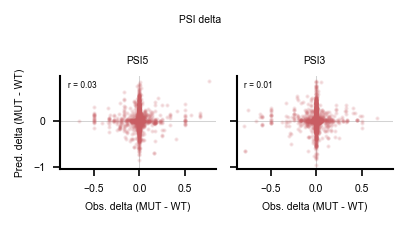

In [ ]:
X = preds["psi_scores"].sample(10000)
KEY = ["chrom", "donor_pos_1based", "acceptor_pos_1based", "strand"]

wt = X.query("sample_id == @WT_SAMPLE").set_index(KEY)[["obs_psi5", "pred_psi5", "obs_psi3", "pred_psi3"]]
mut = X.query("sample_id == @MUT_SAMPLE").set_index(KEY)[["obs_psi5", "pred_psi5", "obs_psi3", "pred_psi3"]]

delta_psi = wt.join(mut, lsuffix="_wt", rsuffix="_mut", how="inner")
delta_psi["obs_psi5_delta"] = delta_psi["obs_psi5_mut"] - delta_psi["obs_psi5_wt"]
delta_psi["pred_psi5_delta"] = delta_psi["pred_psi5_mut"] - delta_psi["pred_psi5_wt"]
delta_psi["obs_psi3_delta"] = delta_psi["obs_psi3_mut"] - delta_psi["obs_psi3_wt"]
delta_psi["pred_psi3_delta"] = delta_psi["pred_psi3_mut"] - delta_psi["pred_psi3_wt"]
delta_psi = delta_psi.reset_index().dropna(subset=["obs_psi5_delta", "obs_psi3_delta"])

psi_types = [
    ("PSI5", "obs_psi5_delta", "pred_psi5_delta"),
    ("PSI3", "obs_psi3_delta", "pred_psi3_delta"),
]

fig, axes = plt.subplots(1, 2, figsize=(7 * cm, 3.5 * cm), sharey=True, sharex=True)
for ax, (label, obs_col, pred_col) in zip(axes, psi_types):
    sub = delta_psi[[obs_col, pred_col]].dropna()
    sub = sub.sample(min(10000, len(sub)), random_state=42)
    r, _ = stats.pearsonr(sub[obs_col], sub[pred_col])
    ax.scatter(sub[obs_col], sub[pred_col],
               s=1, alpha=0.15, rasterized=True,
               color=PAL_MODALITIES["splice_usage"])
    ax.set_title(label, fontsize=5)
    ax.set_xlabel("Obs. delta (MUT - WT)", fontsize=5)
    ax.set_ylabel("Pred. delta (MUT - WT)" if ax is axes[0] else "", fontsize=5)
    ax.text(0.05, 0.95, "r = {:.2f}".format(r), transform=ax.transAxes,
            fontsize=4, va="top")
    ax.tick_params(labelsize=5)
    ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
    ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

fig.suptitle("PSI delta", fontsize=5, y=1.02)
plt.tight_layout()
plt.show()

### Summary figure — all modalities

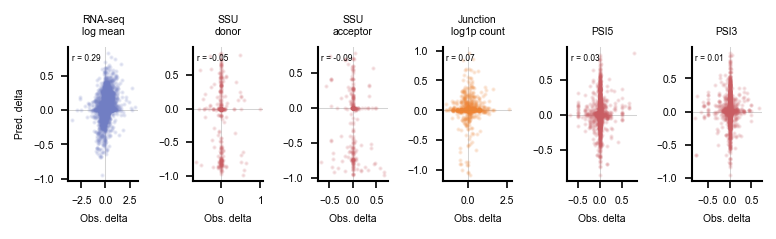

In [ ]:
# one panel per modality comparison: RNA-seq, SSU donor, SSU acceptor, junction, PSI5, PSI3
panels = [
    {
        "title": "RNA-seq\nlog mean",
        "color": PAL_MODALITIES["rna_seq"],
        "data": delta[["obs_delta", "pred_delta"]].dropna(),
        "xlabel": "Obs. delta",
        "ylabel": "Pred. delta",
    },
    {
        "title": "SSU\ndonor",
        "color": PAL_MODALITIES["splice_usage"],
        "data": delta_ssu.query("role == 'donor'")[["obs_delta", "pred_delta"]].dropna(),
        "xlabel": "Obs. delta",
        "ylabel": "Pred. delta",
    },
    {
        "title": "SSU\nacceptor",
        "color": PAL_MODALITIES["splice_usage"],
        "data": delta_ssu.query("role == 'acceptor'")[["obs_delta", "pred_delta"]].dropna(),
        "xlabel": "Obs. delta",
        "ylabel": "Pred. delta",
    },
    {
        "title": "Junction\nlog1p count",
        "color": PAL_MODALITIES["splice_junctions"],
        "data": delta_junc[["obs_delta", "pred_delta"]].dropna(),
        "xlabel": "Obs. delta",
        "ylabel": "Pred. delta",
    },
    {
        "title": "PSI5",
        "color": PAL_MODALITIES["splice_usage"],
        "data": delta_psi[["obs_psi5_delta", "pred_psi5_delta"]].rename(
            columns={"obs_psi5_delta": "obs_delta", "pred_psi5_delta": "pred_delta"}),
        "xlabel": "Obs. delta",
        "ylabel": "Pred. delta",
    },
    {
        "title": "PSI3",
        "color": PAL_MODALITIES["splice_usage"],
        "data": delta_psi[["obs_psi3_delta", "pred_psi3_delta"]].rename(
            columns={"obs_psi3_delta": "obs_delta", "pred_psi3_delta": "pred_delta"}),
        "xlabel": "Obs. delta",
        "ylabel": "Pred. delta",
    },
]

n = len(panels)
fig, axes = plt.subplots(1, n, figsize=(n * 2.2 * cm, 4 * cm))

for ax, panel in zip(axes, panels):
    sub = panel["data"].dropna()
    sub = sub.sample(min(10000, len(sub)), random_state=42)
    r, _ = stats.pearsonr(sub["obs_delta"], sub["pred_delta"])
    ax.scatter(sub["obs_delta"], sub["pred_delta"],
               s=1, alpha=0.15, rasterized=True, color=panel["color"])
    ax.set_title(panel["title"], fontsize=5)
    ax.set_xlabel(panel["xlabel"], fontsize=5)
    ax.set_ylabel(panel["ylabel"] if ax is axes[0] else "", fontsize=5)
    ax.text(0.05, 0.95, "r = {:.2f}".format(r), transform=ax.transAxes,
            fontsize=4, va="top")
    ax.tick_params(labelsize=5)
    ax.axhline(0, color="lightgray", linewidth=0.5, zorder=0)
    ax.axvline(0, color="lightgray", linewidth=0.5, zorder=0)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig(os.path.join("pdfs", "wt_mut_delta.pdf"), bbox_inches="tight")
plt.show()